# Разведывательный анализ пассажиропотока трамвайных маршрутов

**Объект:** успешные валидации по маршруту и календарному часу в московском времени.
История: январь–октябрь 2025. Обучающий период — январь–август,
проверочный — сентябрь–октябрь. Цель `boardings` — число записей с `validation_result = 1`.

Полный аудит исходных 62,4 млн строк выполнен потоково через DuckDB (`ml/data_audit.py`,
`ml/audit_raw.py`). Здесь используются его результаты и компактные маршрутные агрегаты:
ноутбук воспроизводится без загрузки 10 ГБ транзакций в память и без доступа к сети.
Хеши карт и отдельные транзакции не включены. Это повторный анализ результатов полного
аудита, а не повторное чтение raw при каждом запуске ноутбука.

In [1]:
import hashlib
import json
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib.figure import Figure

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "ml/reports").is_dir())
REPORTS = ROOT / "ml/reports"
FIGURES = ROOT / "ml/reports/figures"
FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "figure.figsize": (11, 5),
        "axes.grid": True,
        "grid.alpha": 0.18,
        "axes.axisbelow": True,
        "figure.facecolor": "white",
        "savefig.facecolor": "white",
    }
)
BLUE, TEAL, ORANGE = "#234E70", "#008A85", "#D57433"


def finish(fig: Figure, name: str) -> None:
    fig.tight_layout()
    fig.savefig(FIGURES / f"{name}.png", dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)

## 1. Объём, целевая переменная и контроль исходных данных

In [2]:
audit = json.loads((REPORTS / "data_quality/report.json").read_text(encoding="utf-8"))
raw = json.loads((REPORTS / "eda/raw_reconciliation.json").read_text(encoding="utf-8"))
manifest = json.loads((REPORTS / "eda/manifest.json").read_text(encoding="utf-8"))
for name, digest in manifest["output_sha256"].items():
    assert hashlib.sha256((REPORTS / "eda" / name).read_bytes()).hexdigest() == digest
files = pd.DataFrame(audit["files"]).T
assert int(files.rows.sum()) == 62443497
assert raw["passed"] and all(v["mismatch_keys"] == 0 for v in raw["repartitioned"].values())
display(
    pd.DataFrame(raw["repartitioned"]).T[
        ["raw_boardings", "label_boardings", "label_rows", "mismatch_keys"]
    ]
)
display(files[["rows", "input_before_transaction", "begin_after_transaction"]])

,raw_boardings,label_boardings,label_rows,mismatch_keys
train,46912710,46912710,46234,0
test,12754481,12754481,11317,0


,rows,input_before_transaction,begin_after_transaction
train.csv,49051926,103,11776878
test.csv,13391571,0,3314417


Границы определяются временем `tran_date_time`, а не именем файла. 523 успешные операции
1 сентября из физического train относятся к проверке; 562 операции 1 ноября из test
исключены из истории. После переразбиения число входов совпадает с labels на каждом ключе.
`place_id` обозначает площадку депо, не остановку. GPS и высадок в исходных валидациях нет.

## 2. Пропуски и согласованность полей

,train.csv,test.csv
field,,
pass_route,45.9033,45.0827
begin_date_time,9.7751,10.0559
garage_number,0.7811,0.3607
place_id,0.0003,0.0000
good_type,0.0001,0.0002
bus_exit_no,0.0001,0.0002


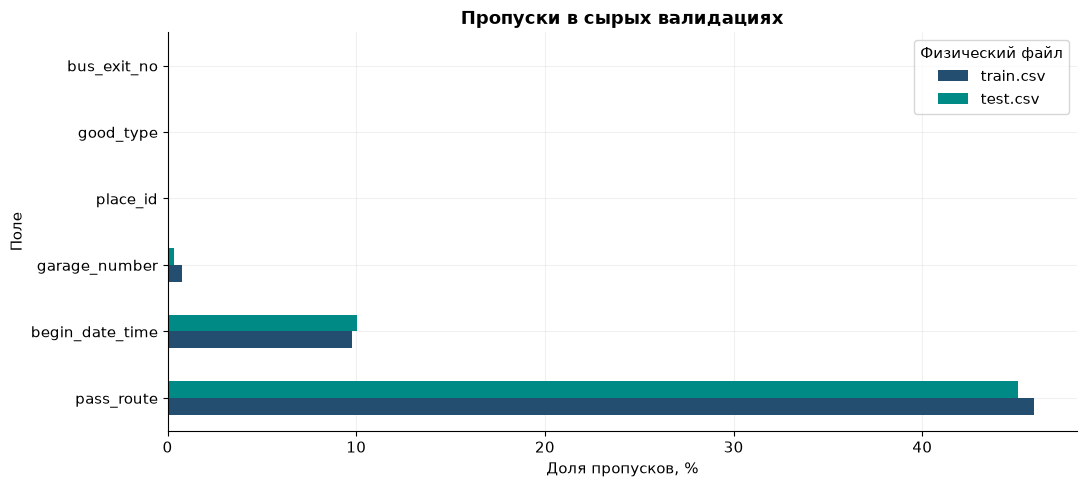

In [3]:
fields = ["pass_route", "begin_date_time", "garage_number", "place_id", "good_type", "bus_exit_no"]
missing = pd.DataFrame(
    {
        split: [
            100 * files.loc[split, f"{field}_missing"] / files.loc[split, "rows"]
            for field in fields
        ]
        for split in files.index
    },
    index=fields,
)
display(missing.rename_axis("field").round(4))
fig, ax = plt.subplots(figsize=(11, 5))
missing.plot.barh(ax=ax, color=[BLUE, TEAL])
ax.set(xlabel="Доля пропусков, %", ylabel="Поле", title="Пропуски в сырых валидациях")
ax.legend(title="Физический файл")
finish(fig, "01_missing_values")

Около 46% `pass_route` отсутствует: такой пропуск нельзя приравнивать к отсутствию пересадки.
Пропуски `bus_exit_no` редки, но будущий выпуск трамваев не известен из этих исторических данных.
Несогласованность `begin_date_time` требует уточнения семантики поля; она не используется
как автоматическое основание удалять посадки.

In [4]:
assert audit["exact_duplicates"]["groups"] == 0
assert audit["targets"]["label_duplicate_keys"] == 0
invalid = files.filter(regex="invalid_|unexpected_card_hash_format").sum(axis=1)
assert invalid.eq(0).all()
display(
    pd.DataFrame(
        {
            "Проверка": [
                "Точные дубли всех 14 полей",
                "Дубли ключей labels",
                "Невалидные значения проверенных типов",
            ],
            "Количество": [0, 0, int(invalid.sum())],
        }
    )
)

,Проверка,Количество
0,Точные дубли всех 14 полей,0
1,Дубли ключей labels,0
2,Невалидные значения проверенных типов,0


## 3. Полнота временной сетки и отсутствие истории маршрута №5

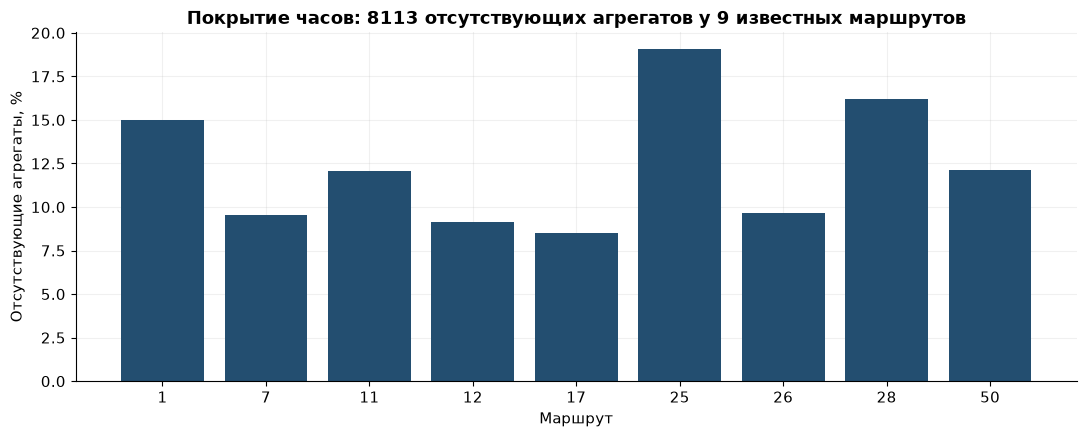

,supplied_hours,grid_hours,absent_hours,zero_days,max_hour
route,,,,,
1,6204,7296,1092,0,2645
7,6600,7296,696,0,5055
11,6416,7296,880,0,3944
12,6629,7296,667,0,4340
17,6677,7296,619,0,5827
25,5904,7296,1392,0,1626
26,6592,7296,704,0,3656
28,6116,7296,1180,0,1783
50,6413,7296,883,1,4276


In [5]:
coverage = pd.read_csv(REPORTS / "data_quality/route_quality.csv", sep=";").set_index("route")
assert int(coverage.grid_hours.sum()) == 65664
assert int(coverage.absent_hours.sum()) == 8113
assert 5 not in coverage.index
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(coverage.index.astype(str), 100 * coverage.absent_hours / coverage.grid_hours, color=BLUE)
ax.set(
    xlabel="Маршрут",
    ylabel="Отсутствующие агрегаты, %",
    title="Покрытие часов: 8113 отсутствующих агрегатов у 9 известных маршрутов",
)
finish(fig, "02_hour_coverage")
display(coverage[["supplied_hours", "grid_hours", "absent_hours", "zero_days", "max_hour"]])

Отсутствующие часы известных маршрутов восстанавливаются нулями по определению счётчика
успешных валидаций. Это не доказывает отсутствие движения или исправность валидаторов.
У №5 отсутствует вся история; его нельзя считать десятым маршрутом с наблюдаемым нулевым
спросом и использовать для искусственного уменьшения MAE.

## 4. Динамика и сезонность

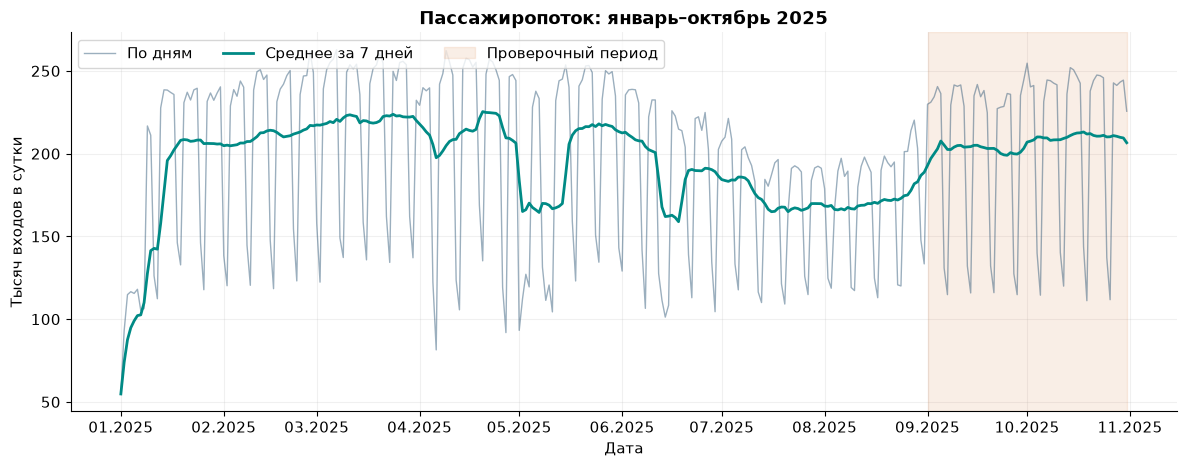

In [6]:
daily = pd.read_csv(REPORTS / "data_quality/daily_counts.csv", sep=";", parse_dates=["date"])
totals = daily.groupby("date")["sum"].sum()
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(totals.index, totals / 1000, color=BLUE, linewidth=1, alpha=0.45, label="По дням")
ax.plot(
    totals.index,
    totals.rolling(7, min_periods=1).mean() / 1000,
    color=TEAL,
    linewidth=2,
    label="Среднее за 7 дней",
)
ax.axvspan(
    pd.Timestamp("2025-09-01"),
    pd.Timestamp("2025-10-31"),
    color=ORANGE,
    alpha=0.12,
    label="Проверочный период",
)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m.%Y"))
ax.set(xlabel="Дата", ylabel="Тысяч входов в сутки", title="Пассажиропоток: январь–октябрь 2025")
ax.legend(ncol=3, loc="upper left")
finish(fig, "03_daily_demand")

Недельные колебания и изменение уровня спроса мотивируют признаки дня недели, часа и сезона.
Семидневная кривая используется только для визуального анализа; она не добавляет будущие
наблюдения в признаки модели.

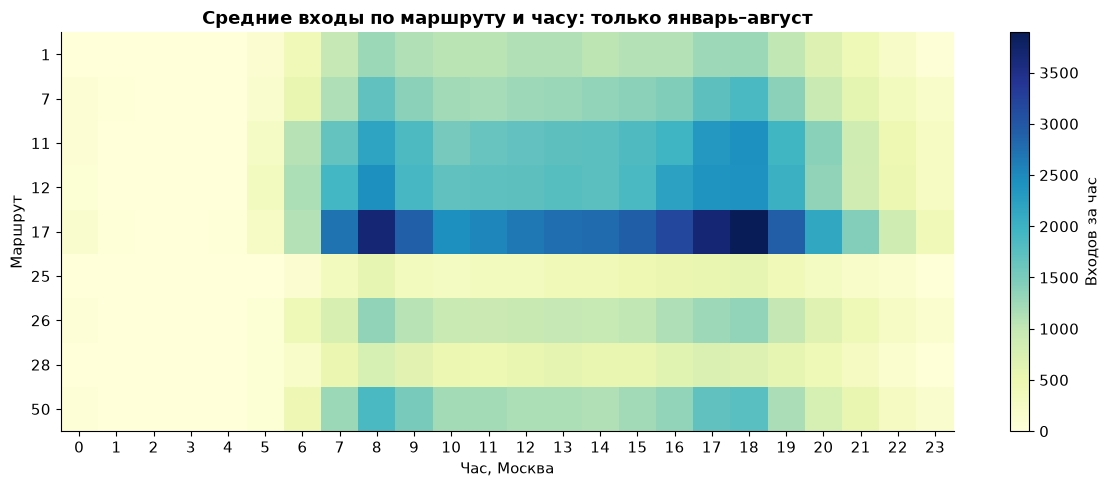

In [7]:
profiles = pd.read_csv(REPORTS / "eda/hourly_profiles.csv", sep=";")
train_profiles = profiles[profiles.split == "train"]
grouped = train_profiles.groupby(["route", "hour"])[["total", "rows"]].sum()
heat = (grouped.total / grouped.rows).unstack("hour")
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(heat.to_numpy(), aspect="auto", cmap="YlGnBu")
ax.set(
    xticks=range(24),
    yticks=range(len(heat)),
    yticklabels=heat.index.astype(str),
    xlabel="Час, Москва",
    ylabel="Маршрут",
    title="Средние входы по маршруту и часу: только январь–август",
)
ax.grid(False)
fig.colorbar(im, ax=ax, label="Входов за час")
finish(fig, "04_route_hour_profiles")

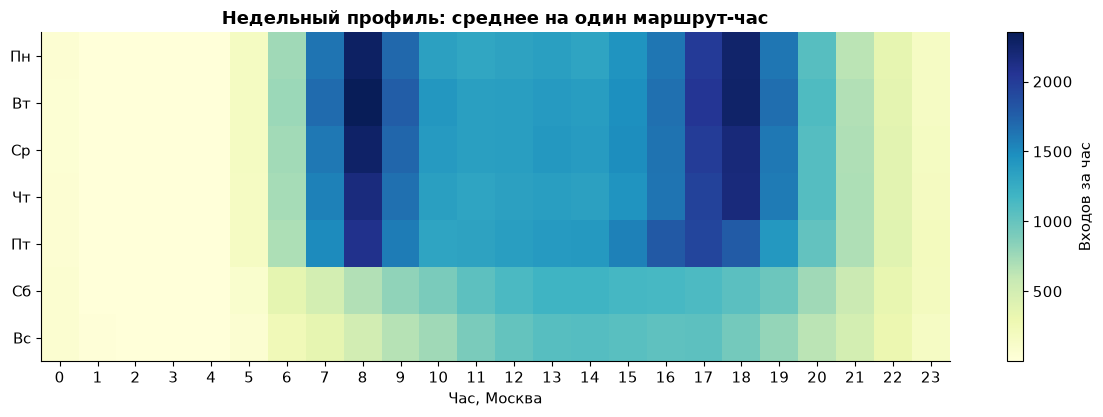

In [8]:
grouped = train_profiles.groupby(["dayofweek", "hour"])[["total", "rows"]].sum()
weekday = (grouped.total / grouped.rows).unstack("hour")
fig, ax = plt.subplots(figsize=(12, 4.3))
im = ax.imshow(weekday.to_numpy(), aspect="auto", cmap="YlGnBu")
ax.set(
    xticks=range(24),
    yticks=range(7),
    yticklabels=["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"],
    xlabel="Час, Москва",
    title="Недельный профиль: среднее на один маршрут-час",
)
ax.grid(False)
fig.colorbar(im, ax=ax, label="Входов за час")
finish(fig, "05_weekday_hour_profiles")

## 5. Различия масштабов маршрутов

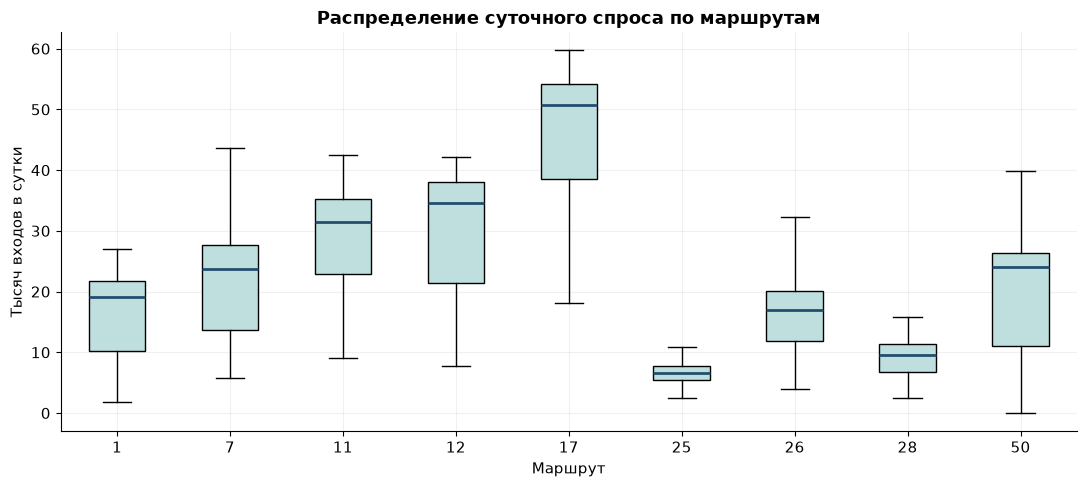

In [9]:
routes = sorted(daily.route.unique())
fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(
    [daily.loc[daily.route == route, "sum"].to_numpy() / 1000 for route in routes],
    tick_labels=[str(r) for r in routes],
    showfliers=False,
    patch_artist=True,
    boxprops={"facecolor": "#BFDFDE"},
    medianprops={"color": BLUE, "linewidth": 2},
)
ax.set(
    xlabel="Маршрут",
    ylabel="Тысяч входов в сутки",
    title="Распределение суточного спроса по маршрутам",
)
finish(fig, "06_route_daily_distribution")

Масштаб спроса заметно различается между маршрутами. Общий WAPE взвешивает ошибки через
суммарный поток; поэтому общую метрику необходимо дополнять маршрутными MAE и WAPE.
На графике выбросы скрыты только для читаемости, исходные наблюдения не удалены.

## 6. Аномалии и границы интерпретации

,route,date,hour,boardings,median,robust_deviation
0,17,2025-04-27,8,7,1149.0,28.528461
1,17,2025-04-13,8,83,1149.0,26.629894
2,17,2025-04-06,8,441,1149.0,17.686647
3,26,2025-04-16,4,161,3.0,15.800000
4,50,2025-08-09,5,180,33.0,14.700000
5,25,2025-04-02,10,934,303.0,13.729151
6,17,2025-04-27,6,2,400.0,13.422366
7,50,2025-07-26,5,167,33.0,13.400000
8,17,2025-04-27,7,3,733.0,12.957322
9,26,2025-04-08,3,127,0.0,12.700000


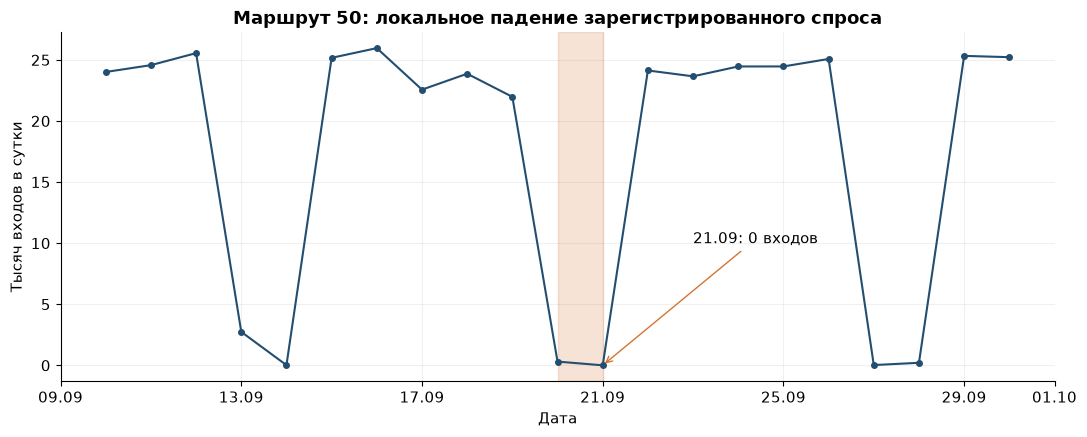

In [10]:
anomalies = pd.read_csv(REPORTS / "data_quality/hourly_anomaly_candidates.csv", sep=";")
assert len(anomalies) == 80
display(anomalies[["route", "date", "hour", "boardings", "median", "robust_deviation"]].head(10))
section = daily[(daily.route == 50) & daily.date.between("2025-09-10", "2025-09-30")]
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(section.date, section["sum"] / 1000, color=BLUE, marker="o", markersize=4)
ax.axvspan(pd.Timestamp("2025-09-20"), pd.Timestamp("2025-09-21"), color=ORANGE, alpha=0.2)
ax.annotate(
    "21.09: 0 входов",
    xy=(pd.Timestamp("2025-09-21"), 0),
    xytext=(pd.Timestamp("2025-09-23"), 10),
    arrowprops={"arrowstyle": "->", "color": ORANGE},
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
ax.set(
    xlabel="Дата",
    ylabel="Тысяч входов в сутки",
    title="Маршрут 50: локальное падение зарегистрированного спроса",
)
finish(fig, "07_route50_anomaly")
assert int(section.loc[section.date.eq("2025-09-21"), "sum"].iloc[0]) == 0

80 часов выделены правилом отклонения от медианы более чем на 8 робастных масштабов.
Медиана и MAD рассчитаны по январю–августу; минимальный масштаб — 10 входов.
Это кандидаты для разбора, не доказанные ошибки. У №50 20 сентября зарегистрировано
304 входа, 21 сентября — ноль. Без дополнительных данных нельзя отделить ограничения
движения от потери регистрации. Эти дни сохранены в оценке качества.

**Выводы для модели:** сохранять часовые и недельные профили; учитывать календарные переносы;
анализировать ошибки отдельно по маршрутам; не использовать будущий выпуск вагонов или
будущие валидации как признаки; №5 оценивать отдельным методом холодного старта.